<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
from torchvision.utils import save_image, make_grid
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
from PIL import Image

%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

data_path = '/kaggle/input/datasets/tommykamaz/faces-dataset-small/faces_dataset_small'

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
class FacesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # берем все .png файлы (или можно другие форматы)
        self.images = [f for f in os.listdir(root_dir) 
                      if f.endswith(('.png', '.jpg', '.jpeg'))]
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, 0  # возвращаем фиктивную метку (можно 0)


def get_dataloader(image_size, batch_size):
    """
    Builds dataloader for training data.

    :param image_size: height and width of images
    :param batch_size: batch size
    :returns: DataLoader object
    """
    transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor(),
        tt.Normalize(          # добавляем здесь
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )
    ])

    dataset = FacesDataset(
        root_dir=data_path,
        transform=transform
    )

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    return dataloader

In [3]:
# параметры
image_size = 128
batch_size = 32

# устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# создаём DataLoader
train_loader = get_dataloader(image_size, batch_size)

print(device)
print(f'Number of batches: {len(train_loader)}')

cuda
Number of batches: 99


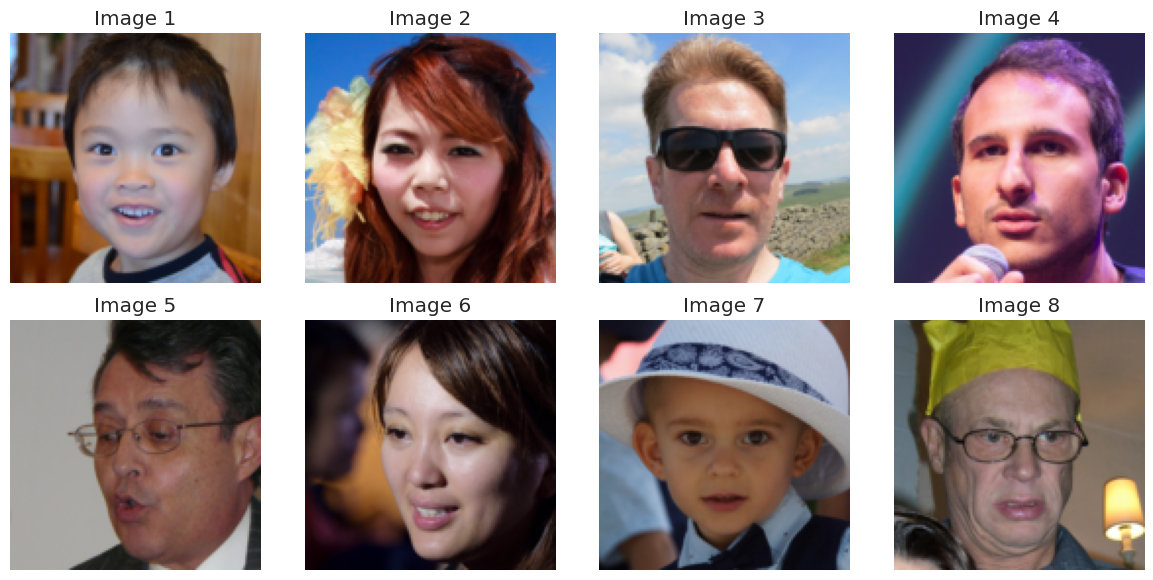

Размер каждого изображения: torch.Size([3, 128, 128])


In [4]:
def visualize_batch(dataloader, num_images=8):
    """Визуализирует батч изображений из DataLoader"""
    images, _ = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, num_images//2, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(min(num_images, len(images))):
        # преобразуем тензор 
        img = images[i].permute(1, 2, 0).numpy()
        # преобразуем в 0, 1
        if img.min() < 0:
            img = (img + 1) / 2
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'Image {i+1}')
    plt.tight_layout()
    plt.show()
    print(f'Размер каждого изображения: {images.shape[1:]}')

# визуализируем примеры
visualize_batch(train_loader, num_images=8)

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [5]:
discriminator = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(512, 1, kernel_size=8),
    nn.Flatten()
)

discriminator = discriminator.to(device)

In [6]:
latent_size = 100

generator = nn.Sequential(
    nn.ConvTranspose2d(latent_size, 1024, 4, 1, 0),
    nn.BatchNorm2d(1024),
    nn.ReLU(True),

    nn.ConvTranspose2d(1024, 512, 4, 2, 1),
    nn.BatchNorm2d(512),
    nn.ReLU(True),

    nn.ConvTranspose2d(512, 256, 4, 2, 1),
    nn.BatchNorm2d(256),
    nn.ReLU(True),

    nn.ConvTranspose2d(256, 128, 4, 2, 1),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.ConvTranspose2d(128, 64, 4, 2, 1),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    nn.ConvTranspose2d(64, 3, 4, 2, 1),
    nn.Tanh()
)

generator = generator.to(device)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [7]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCEWithLogitsLoss(),
    "generator": nn.BCEWithLogitsLoss()
}

In [8]:
def fit(model, criterion, epochs, lr, device):

    D = model['discriminator']
    G = model['generator']

    criterion_D = criterion['discriminator']
    criterion_G = criterion['generator']

    optimizer_D = torch.optim.Adam(
        D.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    optimizer_G = torch.optim.Adam(
        G.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    generator_losses = []
    discriminator_losses = []

    for epoch in range(epochs):
        epoch_G = 0
        epoch_D = 0
        progress = tqdm(train_loader)
        for real_images, _ in progress:
            noise_std = 0.05
            real_images = (
                real_images
                + noise_std * torch.randn_like(real_images)
            ).clamp(-1, 1)
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            real_labels = torch.full((batch_size, 1), 0.9, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            optimizer_D.zero_grad()
            real_pred = D(real_images)
            real_loss = criterion_D(real_pred, real_labels)
            noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = G(noise)
            fake_pred = D(fake_images.detach())
            fake_loss = criterion_D(fake_pred, fake_labels)
            loss_D = real_loss + fake_loss
            loss_D.backward()
            optimizer_D.step()

            
            optimizer_G.zero_grad()
            noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
            generated = G(noise)
            pred = D(generated)
            loss_G = criterion_G(
                pred,
                real_labels
            )
            loss_G.backward()
            optimizer_G.step()
            epoch_D += loss_D.item()
            epoch_G += loss_G.item()
            progress.set_description(
                f'Epoch {epoch+1} '
                f'D={loss_D.item():.3f} '
                f'G={loss_G.item():.3f}'
            )

        generator_losses.append(epoch_G / len(train_loader))
        discriminator_losses.append(epoch_D / len(train_loader))

    return generator_losses, discriminator_losses

In [9]:
epochs = 80

g_loss, d_loss = fit(
    model,
    criterion,
    epochs,
    lr,
    device
)

Epoch 80 D=0.814 G=1.590: 100%|██████████| 99/99 [01:14<00:00,  1.33it/s]


Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

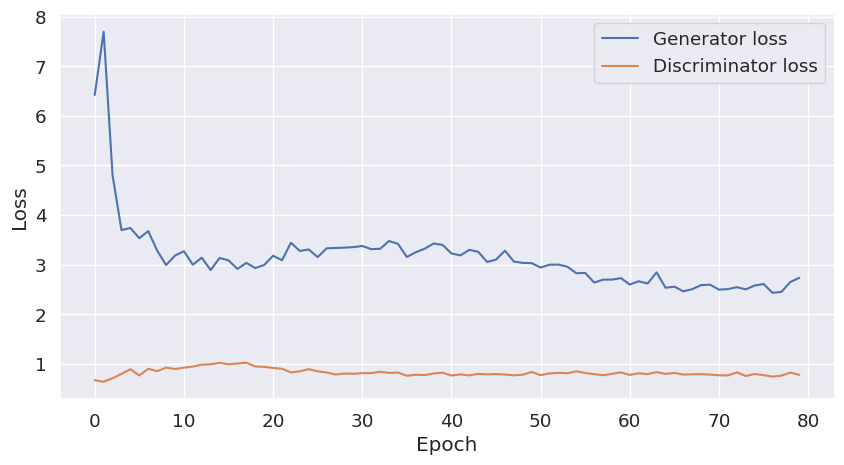

In [10]:
plt.figure(figsize=(10,5))
plt.plot(g_loss, label='Generator loss')
plt.plot(d_loss, label='Discriminator loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [11]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model['generator'](fixed_latent)
print(f'Фиксированный latent вектор создан: {fixed_latent.shape}')


Фиксированный latent вектор создан: torch.Size([4, 100, 1, 1])


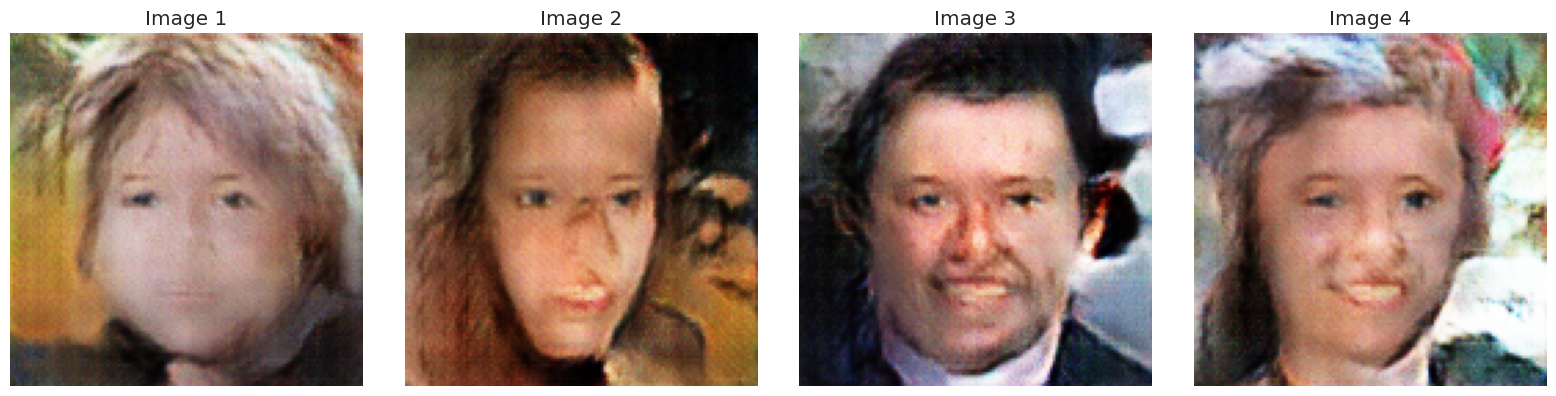

In [12]:
def show_images(generated):
    generated = generated.detach().cpu()
    n_images = generated.shape[0]
    fig, axes = plt.subplots(
        1,
        n_images,
        figsize=(4 * n_images, 4)
    )

    if n_images == 1:
        axes = [axes]
        
    for i in range(n_images):
        img = generated[i]
        img = (img + 1) / 2
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f'Image {i+1}')
    plt.tight_layout()
    plt.show()

show_images(fake_images)

Как вам качество получившихся изображений?

Немного криповато :) Но в целом ничего, может результат стал лучше бы на 100 эпохах, но нет мощностей и возможности столько учить

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [13]:
def calculate_accuracy(model, train_loader, latent_size, device, max_samples=1000):
    generator = model['generator']
    real_images = []
    generator.eval()
    
    with torch.no_grad():
        for images, _ in train_loader:
            real_images.append(images.cpu())
    real_images = torch.cat(real_images, dim=0)
    n_real = len(real_images)
    print(f'Реальных изображений: {n_real}')
    
    fake_images = []
    with torch.no_grad():
        batch_size = 64
        for start in range(0, n_real, batch_size):
            current_batch = min(batch_size, n_real - start)
            noise = torch.randn(current_batch, latent_size, 1, 1, device=device)
            generated = generator(noise)
            fake_images.append(generated.cpu())
    
    fake_images = torch.cat(fake_images, dim=0)
    print(f'Сгенерировано изображений: {len(fake_images)}')
    
    # объединяем реальные и фейковые
    X = torch.cat([real_images, fake_images], dim=0)
    y = np.concatenate([np.ones(n_real), np.zeros(n_real)])
    
    # преобразуем в плоские векторы
    X = X.reshape(X.shape[0], -1).numpy()
    print(f'Размерность признаков: {X.shape[1]}')
    
    # берем подвыборку для ускорения
    if max_samples and max_samples < len(X):
        indices = np.random.choice(len(X), max_samples, replace=False)
        X = X[indices]
        y = y[indices]
        print(f'Размер подвыборки: {len(X)}')
    
    # LeaveOneOut кросс-валидация
    loo = LeaveOneOut()
    predictions = []
    targets = []
    
    knn = KNeighborsClassifier(n_neighbors=1)
    
    for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc='LOO прогресс'):
        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]  
        knn.fit(X_train, y_train)
        pred = knn.predict(X_test)   
        predictions.append(pred[0])
        targets.append(y_test[0])  
    acc = accuracy_score(targets, predictions)
    print(f'1NN Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    generator.train()
    return acc

# вычисляем accuracy
accuracy = calculate_accuracy(
    model=model,           
    train_loader=train_loader,  
    latent_size=latent_size,   
    device=device,         
    max_samples=500       
)

print(f'Итоговая точность классификации: {accuracy*100:.2f}%')

Реальных изображений: 3143
Сгенерировано изображений: 3143
Размерность признаков: 49152
Размер подвыборки: 500


LOO прогресс: 100%|██████████| 500/500 [02:12<00:00,  3.77it/s]

1NN Accuracy: 0.7100 (71.00%)
Итоговая точность классификации: 71.00%


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

Хороший результат, но не идеальный. 50% было бы идельано, то есть дискриминатор слуйно бы угадывал. Можно еще попроборвать менять learning rate, увеличивать эпохи, но как уже написал выше, у меня нет домашних мощностей на все это, а задачи тут добиться нужной метрики не стоит, поэтому непонятно к чему стремиться.

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

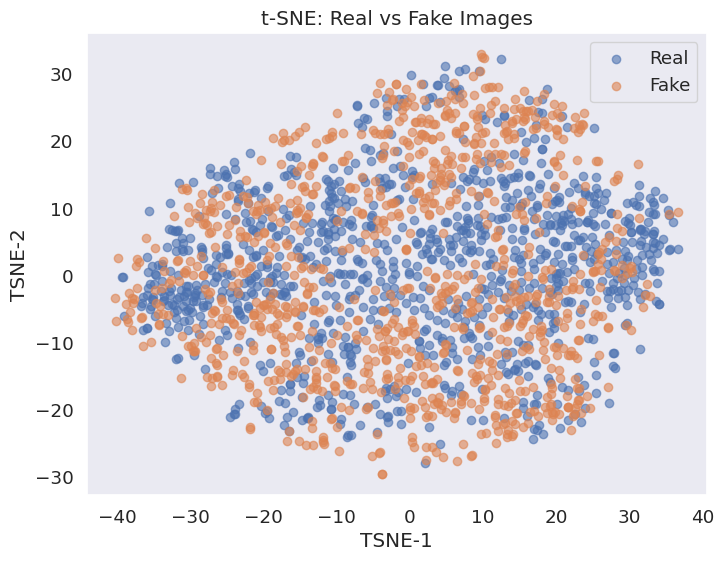

In [14]:

def visualize_distributions(model, train_loader, max_samples=1000):
    generator = model['generator']
    generator.eval()

    real_images = []
    with torch.no_grad():
        for images, _ in train_loader:
            real_images.append(images.cpu())
    real_images = torch.cat(real_images, dim=0)

    n_real = min(max_samples, len(real_images))

    indices = torch.randperm(len(real_images))[:n_real]

    real_images = real_images[indices]

    with torch.no_grad():
        noise = torch.randn(n_real, latent_size, 1, 1, device=device)
        fake_images = generator(noise).cpu()

    real_features = real_images.reshape(n_real, -1)
    fake_features = fake_images.reshape(n_real, -1)

    X = torch.cat([real_features, 
                   fake_features],
                  dim=0).numpy()

    y = np.concatenate([np.ones(n_real),
                        np.zeros(n_real)])

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        init='pca'
    )
    X_embedded = tsne.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X_embedded[y == 1, 0],
                X_embedded[y == 1, 1],
                alpha=0.6,
                label='Real')
    plt.scatter(X_embedded[y == 0, 0],
                X_embedded[y == 0, 1],
                alpha=0.6,
                label='Fake')
    plt.legend()
    plt.title('t-SNE: Real vs Fake Images')
    plt.xlabel('TSNE-1')
    plt.ylabel('TSNE-2')
    plt.grid()
    plt.show()

visualize_distributions(
    model,
    train_loader,
    max_samples=1000
)

Прокомментируйте получившийся результат:

Точки смешаны, но пересекаются неполностью. Это соответствуют моему результаты accuracy в 70%. <br>
Из плюсов можно отметить что данные занимают примерно одинаковую область пространства и кластеры сильно перекрываются. <br>
Из минусов есть области где преобладает один клас. <br>
Для улучшения можно попробовать увеличить размер выборки или перплексии до 50.